<a href="https://colab.research.google.com/github/krasnovaov81-coder/Case_DZ_Netology/blob/main/%D0%9A%D0%B5%D0%B9%D1%81_%D0%B8%D1%81%D1%81%D0%BB%D0%B5%D0%B4%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D1%81%D0%BA%D0%B8%D0%B9_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Учебный кейс: исследовательский анализ данных
*Шаблон для выполнения задания*

**Датасет:** [Used Car Price Prediction Dataset](https://www.kaggle.com/datasets/taeefnajib/used-car-price-prediction-dataset)

## 📊 Описание датасета

В данном задании используется датасет с информацией о продаже подержанных автомобилей, собранной из объявлений.
Датасет содержит 12 признаков. Каждая строка — одно объявление о продаже автомобиля.

**Бизнес-контекст:** вы — аналитик в автодилерской компании. Нужно провести исследовательский анализ данных (EDA) — понять, что находится в датасете, и оценить качество данных.

**Описание признаков:**
- `brand` — марка автомобиля (BMW, Ford, Toyota, …)
- `model` — модель автомобиля
- `model_year` — год выпуска
- `milage` — пробег (мили)
- `fuel_type` — тип топлива (Gasoline, Hybrid, E85 Flex Fuel, Diesel, …)
- `engine` — двигатель (строка: объём, мощность, тип)
- `transmission` — коробка передач (Automatic, Manual, CVT, …)
- `ext_col` — цвет кузова
- `int_col` — цвет салона
- `accident` — были ли ДТП (None / At least 1 accident or damage reported)
- `clean_title` — чистое ли свидетельство о регистрации (Yes / NaN)
- `price` — цена (USD, строка с символом $)



## 1. Импорт библиотек и загрузка данных

Импортируйте библиотеки, которые понадобятся для работы.
Вам точно понадобятся: `pandas`, `matplotlib.pyplot`, `seaborn`.
Опционально (для бонусных задач): `phik`, `missingno`.

In [ ]:
!pip install phik -q
!pip install missingno -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 12.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Дополнительно:
import missingno as msno
import phik

# Импорт основных библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Опциональный импорт для бонусных задач
# import missingno as msno
# import phik

# Настройки отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Настройки графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

# Загрузка данных
df = pd.read_csv('used_cars.csv')

# Проверка результата
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 4009 строк, 12 столбцов


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


## 2. Первичный осмотр данных

Проведите инвентаризацию датасета. Ответьте на вопросы:
- Сколько строк?
- Какие типы данных у каждого столбца? Есть ли неожиданные типы?
- Как выглядят базовые статистики по признаками?
- Какие «красные флаги» вы замечаете уже на этом этапе?

In [ ]:
print(f'Размер датасета: {df.shape}')
display(df.head())
display(df.info())
display(df.describe(include='all').T)

Размер датасета: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capability,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric Hybrid,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand,4009,57,Ford,386,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,4009,1898,M3 Base,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_year,4009.00,NaN,NaN,NaN,2015.52,6.10,1974.00,2012.00,2017.00,2020.00,2024.00
milage,4009,2818,"110,000 mi.",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_type,3839,7,Gasoline,3309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,4009,1146,2.0L I4 16V GDI DOHC Turbo,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,4009,62,A/T,1037,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext_col,4009,319,Black,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_col,4009,156,Black,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accident,3896,2,None reported,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Ваши наблюдения по первичному осмотру:**
- milage хранится как строка, например 51,000 mi., хотя это числовой показатель.

- price также хранится как строка с символом $.

- model_year уже имеет корректный целочисленный тип.

- clean_title содержит только значение Yes и пропуски, то есть фактически это бинарный признак с неизвестным смыслом пропуска.

- В transmission много вариантов записи одной и той же категории: A/T, Automatic, 8-Speed A/T, 8-Speed Automatic и другие.

- В fuel_type встречаются нестандартные значения – и not supported.

- Среднее значение цены значительно выше медианы, что указывает на наличие дорогих автомобилей и сильную асимметрию распределения.

- В датасете представлены 57 марок, 1898 моделей и 1146 вариантов описания двигателя.

## 3. Качество данных: пропуски и дубликаты

Исследуйте полноту и чистоту данных:
- В каких столбцах есть пропуски? Какова их доля (в %)?
- Есть ли полные дубликаты строк?
- Есть ли частичные дубликаты?
- Какие решения вы принимаете по каждому типу проблемы?


💡 *Бонус (необязательное задание):* попробуйте библиотеку `missingno` для визуализации пропусков.

***Пропуски***

In [ ]:
missing = (
    df.isna()
      .sum()
      .to_frame('missing_count')
      .assign(missing_pct=lambda x: x['missing_count'] / len(df) * 100)
      .sort_values('missing_pct', ascending=False)
)

display(missing)

,missing_count,missing_pct
clean_title,596,14.87
fuel_type,170,4.24
accident,113,2.82
brand,0,0.00
milage,0,0.00
model_year,0,0.00
model,0,0.00
engine,0,0.00
ext_col,0,0.00
transmission,0,0.00


| Столбец           | Количество | Доля   |
| ----------------- | ---------- | ------ |
| clean_title       | 596        | 14,87% |
| fuel_type         | 170        | 4,24%  |
| accident          | 113        | 2,82%  |
| Остальные столбцы | 0          | 0%     |

***Полные дубликаты***

In [ ]:
df.duplicated().sum()

np.int64(0)

Полных дубликатов нет

Частичные дубликаты.
Проверим потенциальный бизнес-ключ

In [ ]:
key_columns = ['brand', 'model', 'model_year', 'milage']

partial_duplicates = df.duplicated(
    subset=key_columns,
    keep=False
)

print(partial_duplicates.sum())
display(df.loc[partial_duplicates].sort_values(key_columns))

6


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
827,Ford,F-250 Lariat,2019,"85,000 mi.",Diesel,450.0HP 6.7L 8 Cylinder Engine Diesel Fuel,6-Speed A/T,White,Black,At least 1 accident or damage reported,Yes,"$55,000"
1940,Ford,F-250 Lariat,2019,"85,000 mi.",Diesel,450.0HP 6.7L 8 Cylinder Engine Diesel Fuel,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$52,500"
122,Rivian,R1S Adventure Package,2023,"2,500 mi.",NaN,835.0HP Electric Motor Electric Fuel System,A/T,Green,White,None reported,Yes,"$94,000"
472,Rivian,R1S Adventure Package,2023,"2,500 mi.",NaN,835.0HP Electric Motor Electric Fuel System,A/T,Gray,Gray,None reported,Yes,"$91,000"
526,Rivian,R1S Adventure Package,2023,250 mi.,NaN,835.0HP Electric Motor Electric Fuel System,A/T,Red,Black,NaN,NaN,"$94,000"
2184,Rivian,R1S Adventure Package,2023,250 mi.,NaN,835.0HP Electric Motor Electric Fuel System,1-Speed A/T,Green,Black,NaN,NaN,"$97,500"


Было найдено 3 строки, совпадающие по марке, модели, году выпуска и пробегу. Их нельзя автоматически удалять: это могут быть разные объявления одного автомобиля или действительно дубли. Для удаления частичных дублей желательно использовать уникальный listing_id, VIN или ссылку на объявление.

**Опишите найденные проблемы и ваши решения:**

- Решения по проблемам
- Полные дубликаты отсутствуют, поэтому удалять строки по этому критерию не требуется.

- Пропуски в fuel_type не следует автоматически заменять на Gasoline: тип топлива нельзя надёжно восстановить только по частоте.

- Пропуски в accident лучше заменить на отдельную категорию Unknown, поскольку отсутствие информации не означает отсутствие ДТП.

- Пропуски в clean_title также лучше сохранить как Unknown, а не трактовать как No.

- Значения – и not supported в fuel_type следует перевести в Unknown.

## 4. Очистка и подготовка данных

Подготовьте данные к анализу:
- Преобразуйте столбцы с некорректными типами
- Обработайте пропуски (заполните, удалите или оставьте — с обоснованием)
- При необходимости удалите ненужные столбцы


In [ ]:
clean = df.copy()

# Преобразование пробега в число
clean['milage'] = (
    clean['milage']
    .str.replace(r'[^0-9.]', '', regex=True)
    .replace('', np.nan)
    .astype(float)
)

# Преобразование цены в число
clean['price'] = (
    clean['price']
    .str.replace(r'[^0-9.]', '', regex=True)
    .astype(float)
)

# Стандартизация пропусков в категориальных признаках
clean['fuel_type'] = (
    clean['fuel_type']
    .replace({'–': np.nan, 'not supported': np.nan})
    .fillna('Unknown')
)

clean['accident'] = clean['accident'].fillna('Unknown')
clean['clean_title'] = clean['clean_title'].fillna('Unknown')

# Возраст автомобиля относительно последнего года в данных
clean['car_age'] = clean['model_year'].max() - clean['model_year']

clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   float64
 4   fuel_type     4009 non-null   object 
 5   engine        4009 non-null   object 
 6   transmission  4009 non-null   object 
 7   ext_col       4009 non-null   object 
 8   int_col       4009 non-null   object 
 9   accident      4009 non-null   object 
 10  clean_title   4009 non-null   object 
 11  price         4009 non-null   float64
 12  car_age       4009 non-null   int64  
dtypes: float64(2), int64(2), object(9)
memory usage: 407.3+ KB


**Поясните каждое действие:**

1. milage очищен от запятых, единиц измерения и точек.

2. price очищен от символа $ и запятых.

3. Цена и пробег преобразованы в float, что позволяет строить графики, рассчитывать корреляции и обучать модели.

4. Пропуски в категориальных признаках заменены на Unknown, чтобы не терять строки.

5. Значения – и not supported в fuel_type считаются неизвестными.

6. Добавлен признак car_age, который удобнее интерпретировать в ценовом анализе, чем только год выпуска.

## 5. Анализ распределений

Исследуйте, как распределены числовые признаки:
- Постройте гистограммы для ключевых числовых признаков
- Есть ли скошенность распределений? Где находится основная масса значений?
- Сравните среднее и медиану — сильно ли они различаются?
- Постройте boxplot для поиска выбросов

💡 Инструменты: `.hist()`, `sns.histplot()`, `sns.boxplot()`, `plt.subplots()`, `.axvline()` для mean/median, `.mean()`, `.median()`, `.quantile()`.

***Распределения числовых признаков***

Основные статистики числовых признаков:



,count,mean,median,min,max
model_year,4009.00,2015.52,2017.00,1974.00,2024.00
milage,4009.00,64717.55,52775.00,100.00,405000.00
price,4009.00,44553.19,31000.00,2000.00,2954083.00


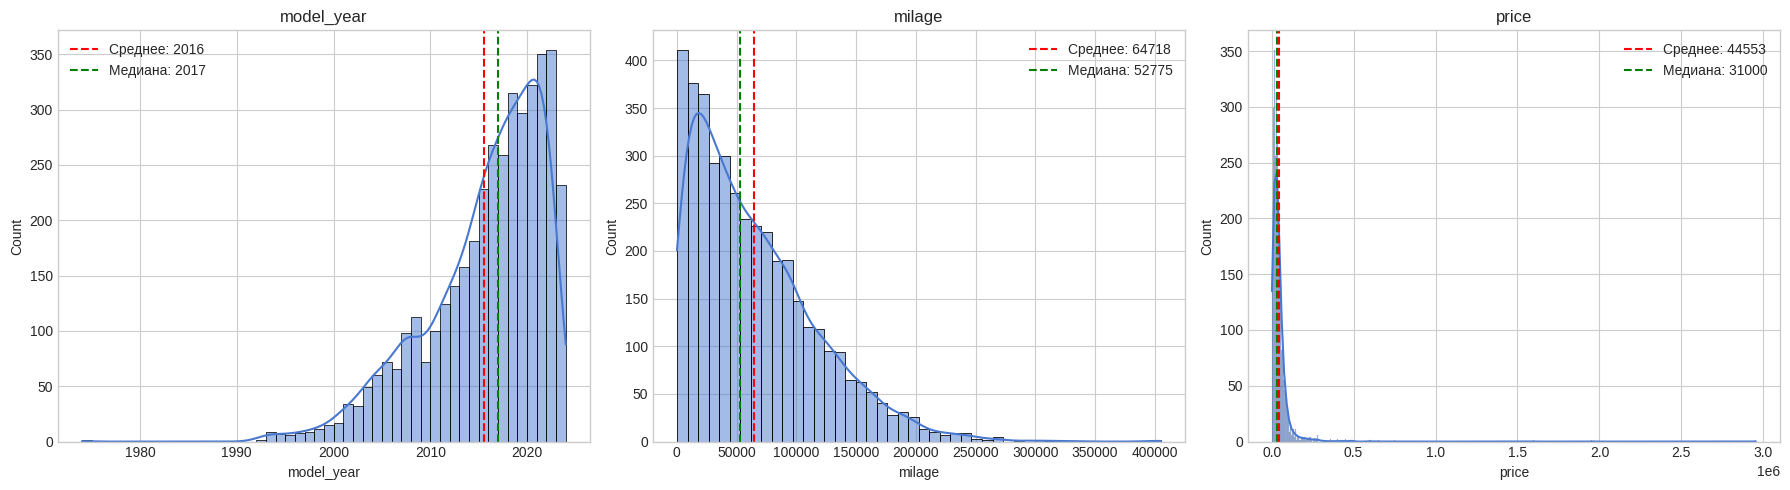

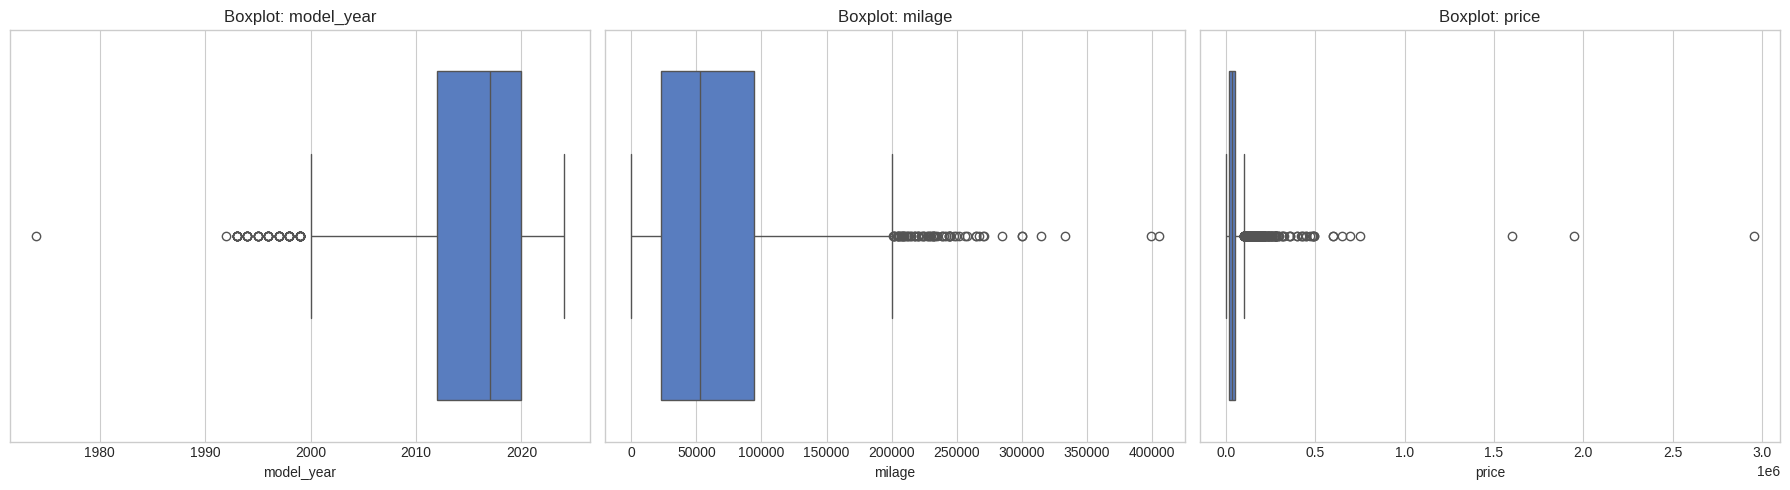

In [ ]:
# Выбор числовых столбцов для анализа
numeric_columns = ['model_year', 'milage', 'price']

# Расчёт основных статистик
stats = clean[numeric_columns].agg(['count', 'mean', 'median', 'min', 'max']).T

print('Основные статистики числовых признаков:\n')
display(stats)

# Построение гистограмм
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, numeric_columns):
    sns.histplot(clean[column], kde=True, ax=ax)
    ax.axvline(clean[column].mean(), color='red', linestyle='--',
               label=f'Среднее: {clean[column].mean():.0f}')
    ax.axvline(clean[column].median(), color='green', linestyle='--',
               label=f'Медиана: {clean[column].median():.0f}')
    ax.set_title(column)
    ax.legend()

plt.tight_layout()
plt.show()

# Построение boxplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, column in zip(axes, numeric_columns):
    sns.boxplot(x=clean[column], ax=ax)
    ax.set_title(f'Boxplot: {column}')

plt.tight_layout()
plt.show()

In [ ]:
# Функция для расчёта границ и количества выбросов по правилу Тьюки
def tukey_outliers(series, column_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_low = (series < lower_bound).sum()
    outliers_high = (series > upper_bound).sum()
    outliers_total = outliers_low + outliers_high

    result = pd.DataFrame({
        'column': [column_name],
        'Q1': [Q1],
        'Q3': [Q3],
        'IQR': [IQR],
        'lower_bound': [lower_bound],
        'upper_bound': [upper_bound],
        'outliers_low': [outliers_low],
        'outliers_high': [outliers_high],
        'outliers_total': [outliers_total]
    })

    return result

# Применение к числовым столбцам
numeric_columns = ['model_year', 'milage', 'price']

tukey_results = pd.concat([
    tukey_outliers(clean[col], col)
    for col in numeric_columns
], ignore_index=True)

display(tukey_results)

# Детализация для price
price_Q1 = clean['price'].quantile(0.25)
price_Q3 = clean['price'].quantile(0.75)
price_IQR = price_Q3 - price_Q1

price_lower = price_Q1 - 1.5 * price_IQR
price_upper = price_Q3 + 1.5 * price_IQR

print(f'\nЦена: Q1 = {price_Q1:.0f}, Q3 = {price_Q3:.0f}, IQR = {price_IQR:.0f}')
print(f'Нижняя граница: {price_lower:.0f}')
print(f'Верхняя граница: {price_upper:.0f}')
print(f'Выбросов снизу: {(clean["price"] < price_lower).sum()}')
print(f'Выбросов сверху: {(clean["price"] > price_upper).sum()}')
print(f'Всего выбросов: {((clean["price"] < price_lower) | (clean["price"] > price_upper)).sum()}')

,column,Q1,Q3,IQR,lower_bound,upper_bound,outliers_low,outliers_high,outliers_total
0,model_year,2012.00,2020.00,8.00,2000.00,2032.00,67,0,67
1,milage,23044.00,94100.00,71056.00,-83540.00,200684.00,0,69,69
2,price,17200.00,49990.00,32790.00,-31985.00,99175.00,0,244,244



Цена: Q1 = 17200, Q3 = 49990, IQR = 32790
Нижняя граница: -31985
Верхняя граница: 99175
Выбросов снизу: 0
Выбросов сверху: 244
Всего выбросов: 244


**Какие закономерности вы видите? Какие выбросы бросаются в глаза?**

Наблюдения
1. Год выпуска.Распределение смещено в сторону более новых автомобилей:
- основная масса автомобилей выпущена примерно в 2012–2023 годах;
- медианный год выпуска — 2017;
- среднее ниже медианы из-за небольшого количества старых автомобилей;
- автомобиль 1974 года является редким наблюдением и требует проверки.

2. Пробег. Распределение пробега имеет правый хвост:
- медианный пробег — 52 775 миль;
- средний пробег выше медианы — 64 718 миль;
- 75% автомобилей имеют пробег не более 94 100 миль;
- максимальный пробег — 405 000 миль;
- по правилу Тьюки обнаружено около 69 выбросов.
Выбросы пробега не обязательно являются ошибками: автомобили с большим пробегом действительно могут продаваться. Их следует проверять, а не удалять автоматически.

3. Цена. Цена имеет крайне сильную правую асимметрию:
- медиана — 31 000 долларов;
- среднее — 44 553 доллара;
- максимальная цена — 2 954 083 доллара;
- по правилу Тьюки обнаружено около 244 выбросов.
Такая цена может быть результатом:
- очень дорогого автомобиля;
- ошибки ввода;
- коллекционной модели;
- ошибочного значения в исходном объявлении.
Для анализа цены полезно использовать:
python
clean['log_price'] = np.log1p(clean['price'])
Логарифмирование уменьшит влияние дорогих автомобилей и часто улучшает качество ценовой модели.

In [ ]:
clean['log_price'] = np.log1p(clean['price'])

## 6. Категориальный анализ и поиск взаимосвязей

Исследуйте категориальные признаки и связи между переменными:
- Какие марки авто представлены чаще всего?
- Как распределены типы топлива, КПП, история ДТП?
- Как цена зависит от года выпуска, пробега, марки?
- Есть ли различия в ценах между авто с ДТП и без?
- Постройте корреляционную матрицу — какие признаки сильнее всего связаны с ценой?


💡 *Бонус (необязательное задание):* попробуйте корреляцию φk через `.phik_matrix(interval_cols=)` из библиотеки `phik` — она работает с категориальными признаками лучше, чем Пирсон.

***6.1. Какие марки авто представлены чаще всего***

=== 6.1. Топ-10 марок автомобилей ===



,count
brand,
Ford,386
BMW,375
Mercedes-Benz,315
Chevrolet,292
Porsche,201
Audi,200
Toyota,199
Lexus,163
Jeep,143


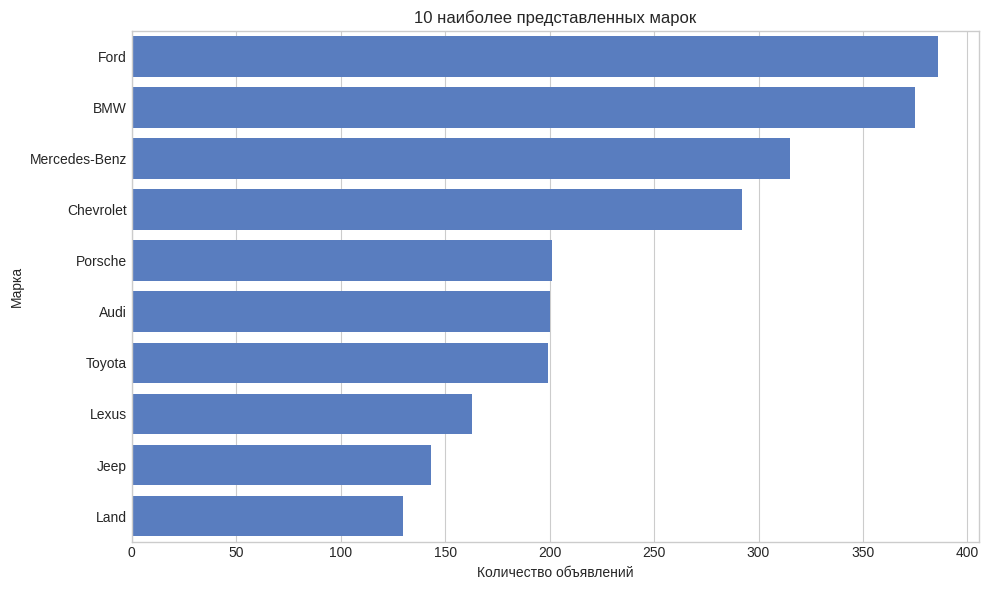

In [ ]:
# 6.1. Топ-10 марок автомобилей
print('=== 6.1. Топ-10 марок автомобилей ===\n')

brand_counts = clean['brand'].value_counts().head(10).to_frame('count')
display(brand_counts)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=brand_counts['count'].values,
    y=brand_counts.index
)
plt.title('10 наиболее представленных марок')
plt.xlabel('Количество объявлений')
plt.ylabel('Марка')
plt.tight_layout()
plt.show()

Наиболее часто встречаются Ford, BMW и Mercedes-Benz.

***6.2. Распределение типа топлива***


=== 6.2. Распределение типа топлива ===



,share,pct
fuel_type,,
Gasoline,0.83,82.54
Unknown,0.05,5.41
Hybrid,0.05,4.84
E85 Flex Fuel,0.03,3.47
Diesel,0.03,2.89
Plug-In Hybrid,0.01,0.85


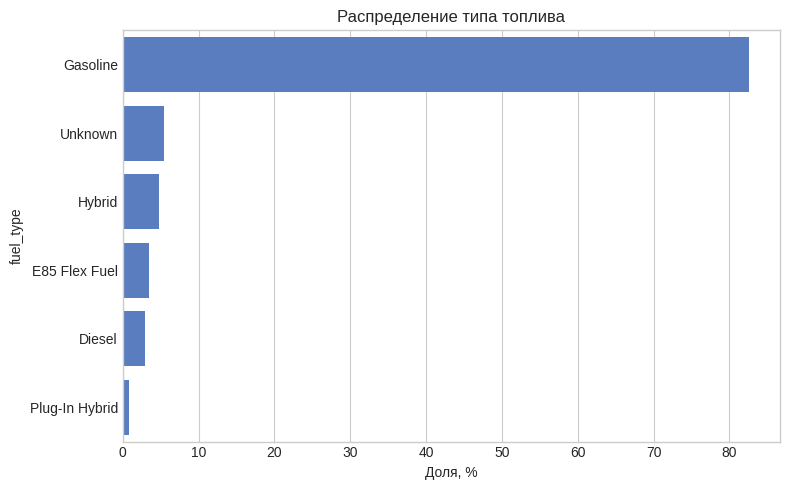

In [ ]:
# 6.2. Распределение типа топлива
print('\n=== 6.2. Распределение типа топлива ===\n')

fuel_type_dist = (
    clean['fuel_type']
    .value_counts(normalize=True)
    .to_frame('share')
    .assign(pct=lambda x: x['share'].mul(100).round(2))
)
display(fuel_type_dist)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=fuel_type_dist['pct'].values,
    y=fuel_type_dist.index
)
plt.title('Распределение типа топлива')
plt.xlabel('Доля, %')
plt.tight_layout()
plt.show()

Бензиновые автомобили составляют более 82% датасета.

***6.3. Распределение типа КПП***


=== 6.3. Распределение типа КПП (топ-15) ===



,share,pct
transmission,,
A/T,0.26,25.87
8-Speed A/T,0.10,10.13
Transmission w/Dual Shift Mode,0.10,9.93
6-Speed A/T,0.09,9.03
6-Speed M/T,0.06,6.19
Automatic,0.06,5.91
7-Speed A/T,0.05,5.21
8-Speed Automatic,0.04,4.39
10-Speed A/T,0.03,2.97


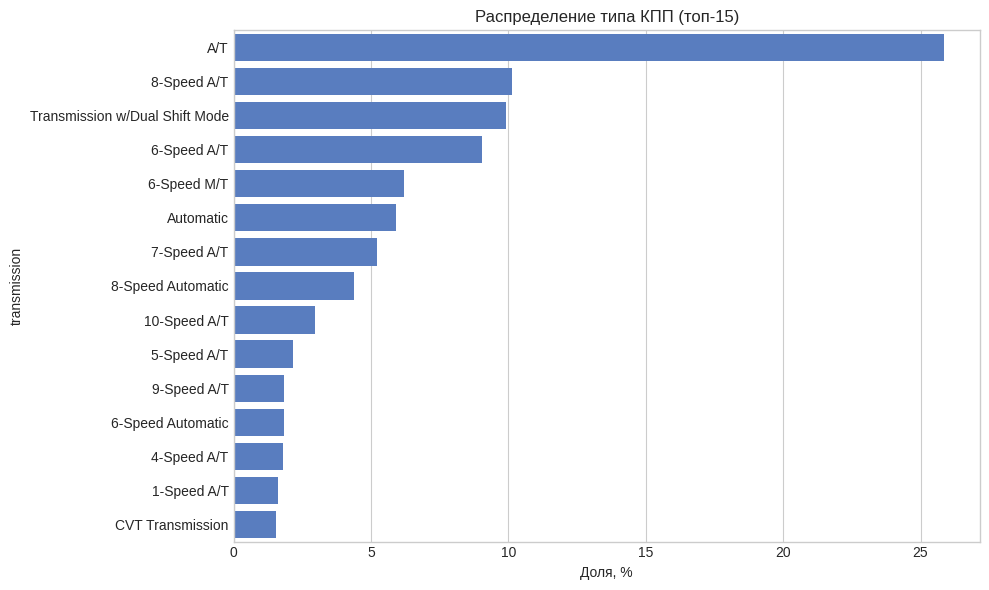

In [ ]:
# 6.3. Распределение типа КПП (топ-15)
print('\n=== 6.3. Распределение типа КПП (топ-15) ===\n')

transmission_dist = (
    clean['transmission']
    .value_counts(normalize=True)
    .head(15)
    .to_frame('share')
    .assign(pct=lambda x: x['share'].mul(100).round(2))
)
display(transmission_dist)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=transmission_dist['pct'].values,
    y=transmission_dist.index
)
plt.title('Распределение типа КПП (топ-15)')
plt.xlabel('Доля, %')
plt.tight_layout()
plt.show()

Автоматические коробки передач доминируют. Варианты A/T и Automatic следует объединить при дальнейшем анализе.

***6.4. История ДТП***


=== 6.4. История ДТП ===



,share,pct
accident,,
None reported,0.73,72.59
At least 1 accident or damage reported,0.25,24.59
Unknown,0.03,2.82


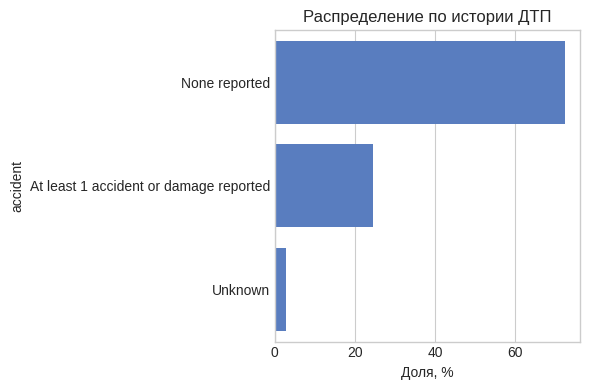

In [ ]:
# 6.4. История ДТП
print('\n=== 6.4. История ДТП ===\n')

accident_dist = (
    clean['accident']
    .value_counts(normalize=True)
    .to_frame('share')
    .assign(pct=lambda x: x['share'].mul(100).round(2))
)
display(accident_dist)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=accident_dist['pct'].values,
    y=accident_dist.index
)
plt.title('Распределение по истории ДТП')
plt.xlabel('Доля, %')
plt.tight_layout()
plt.show()

Около 73% автомобилей не имеют зарегистрированных ДТП, 25% — имеют как минимум одно.

***6.5. Чистое свидетельство о регистрации***


=== 6.5. Чистое свидетельство о регистрации ===



,share,pct
clean_title,,
Yes,0.85,85.13
Unknown,0.15,14.87


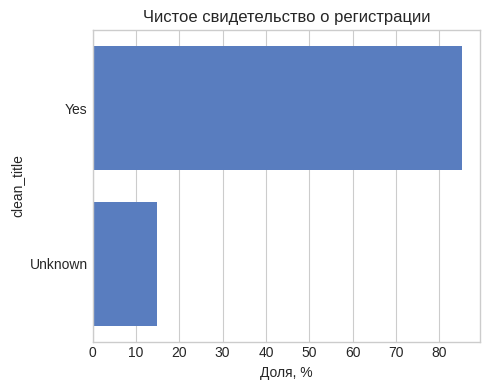

In [ ]:
# 6.5. Чистое свидетельство о регистрации
print('\n=== 6.5. Чистое свидетельство о регистрации ===\n')

clean_title_dist = (
    clean['clean_title']
    .value_counts(normalize=True)
    .to_frame('share')
    .assign(pct=lambda x: x['share'].mul(100).round(2))
)
display(clean_title_dist)

plt.figure(figsize=(5, 4))
sns.barplot(
    x=clean_title_dist['pct'].values,
    y=clean_title_dist.index
)
plt.title('Чистое свидетельство о регистрации')
plt.xlabel('Доля, %')
plt.tight_layout()
plt.show()

У 85% автомобилей чистое свидетельство, у 15% информация отсутствует.

***6.6. Как цена зависит от истории ДТП***


=== 6.6. Цена по истории ДТП ===



,count,mean,median
accident,,,
Unknown,113,50788.39,36500.00
None reported,2910,49638.07,35667.50
At least 1 accident or damage reported,986,28831.50,20900.00


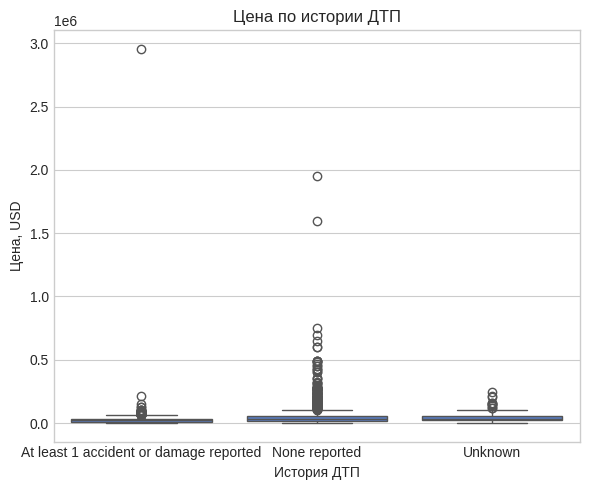

In [ ]:
# 6.6. Цена по истории ДТП
print('\n=== 6.6. Цена по истории ДТП ===\n')

accident_price = (
    clean.groupby('accident')['price']
    .agg(['count', 'mean', 'median'])
    .sort_values('median', ascending=False)
)
display(accident_price)

plt.figure(figsize=(6, 5))
sns.boxplot(
    data=clean,
    x='accident',
    y='price'
)
plt.title('Цена по истории ДТП')
plt.xlabel('История ДТП')
plt.ylabel('Цена, USD')
plt.tight_layout()
plt.show()

Автомобили с ДТП имеют медианную цену на 41% ниже, чем автомобили без зарегистрированных ДТП.

***6.7. Как цена зависит от года выпуска***


=== 6.7. Цена по году выпуска ===



,count,mean,median
model_year,,,
1974,1,115000.00,115000.00
1992,1,11500.00,11500.00
1993,9,22522.11,15300.00
1994,7,7539.86,6000.00
1995,6,25665.33,12999.50
1996,8,22437.38,16249.50
1997,9,11611.00,8500.00
1998,11,12670.82,10300.00
1999,15,12084.67,9500.00


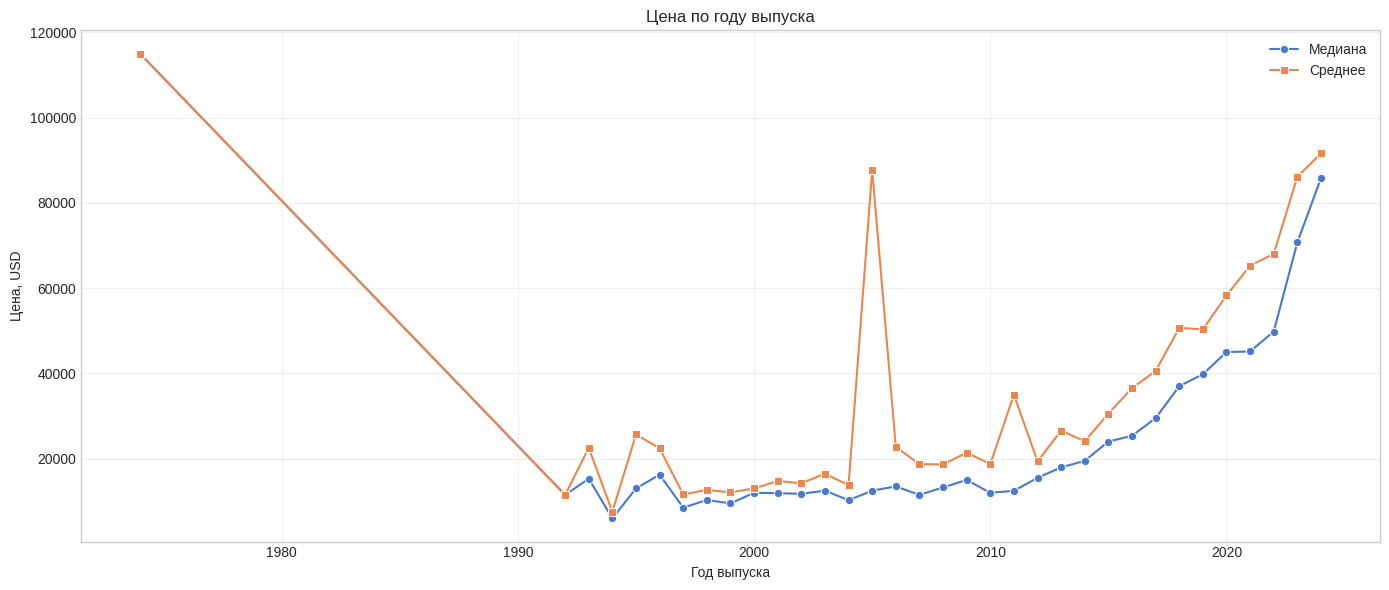

In [ ]:
# 6.7. Цена по году выпуска
print('\n=== 6.7. Цена по году выпуска ===\n')

year_price = (
    clean.groupby('model_year')['price']
    .agg(['count', 'mean', 'median'])
)
display(year_price)

plt.figure(figsize=(14, 6))
year_stats = year_price.reset_index()
sns.lineplot(
    data=year_stats,
    x='model_year',
    y='median',
    marker='o',
    label='Медиана'
)
sns.lineplot(
    data=year_stats,
    x='model_year',
    y='mean',
    marker='s',
    label='Среднее'
)
plt.title('Цена по году выпуска')
plt.xlabel('Год выпуска')
plt.ylabel('Цена, USD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Цена растёт с увеличением года выпуска.

***6.8. Как цена зависит от марки***


=== 6.8. Цена по маркам (топ-15 по количеству) ===



,count,mean,median
brand,,,
Ford,386,36240.88,32377.50
BMW,375,41072.31,32999.00
Mercedes-Benz,315,52075.77,38598.00
Chevrolet,292,36722.74,31992.50
Porsche,201,88751.30,59900.00
Audi,200,39907.43,34497.50
Toyota,199,30026.00,27999.00
Lexus,163,35668.52,30000.00
Jeep,143,31099.79,30000.00


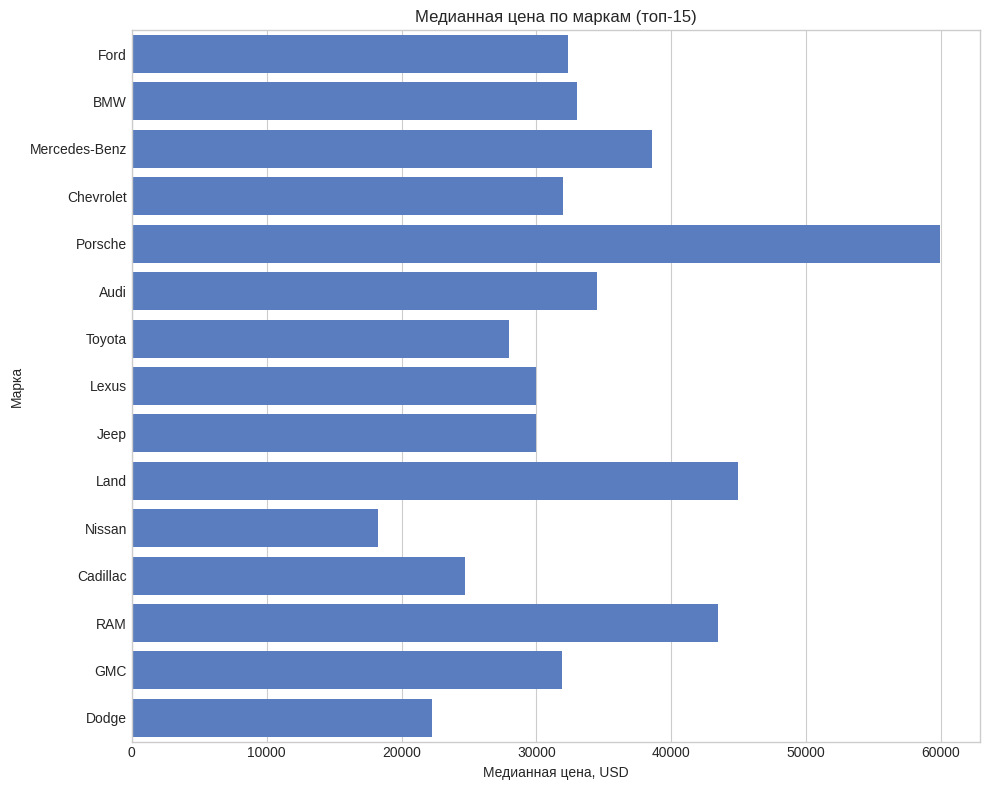

In [ ]:
# 6.8. Цена по маркам (топ-15 по количеству)
print('\n=== 6.8. Цена по маркам (топ-15 по количеству) ===\n')

brand_price = (
    clean.groupby('brand')['price']
    .agg(['count', 'mean', 'median'])
    .query('count >= 30')
    .sort_values('count', ascending=False)
    .head(15)
)
display(brand_price)

plt.figure(figsize=(10, 8))
brand_stats = brand_price.reset_index()
sns.barplot(
    data=brand_stats,
    x='median',
    y='brand'
)
plt.title('Медианная цена по маркам (топ-15)')
plt.xlabel('Медианная цена, USD')
plt.ylabel('Марка')
plt.tight_layout()
plt.show()

Porsche и Land Rover имеют значительно более высокие медианные цены, чем массовые марки.

***6.9. Корреляционная матрица***


=== 6.9. Корреляционная матрица числовых признаков ===



,model_year,milage,price
model_year,1.00,-0.62,0.20
milage,-0.62,1.00,-0.31
price,0.20,-0.31,1.00


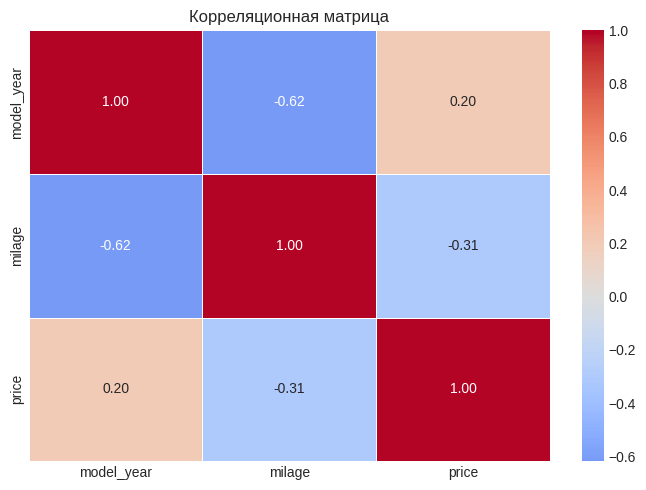

In [ ]:
# 6.9. Корреляционная матрица числовых признаков
print('\n=== 6.9. Корреляционная матрица числовых признаков ===\n')

corr = clean[['model_year', 'milage', 'price']].corr()
display(corr)

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.show()

Год выпуска и пробег сильно отрицательно коррелируют (−0,62).
Цена положительно связана с годом выпуска (0,20) и отрицательно с пробегом (−0,31).

***6.10. Сводная таблица: цена по марке и истории ДТП***

In [ ]:
# 6.10. Сводная таблица: медианная цена по марке и истории ДТП
print('\n=== 6.10. Сводная таблица: медианная цена по марке и истории ДТП ===\n')

pivot_price = (
    clean.pivot_table(
        values='price',
        index='brand',
        columns='accident',
        aggfunc='median'
    )
    .fillna('N/A')
)
display(pivot_price.head(10))


=== 6.10. Сводная таблица: медианная цена по марке и истории ДТП ===



accident,At least 1 accident or damage reported,None reported,Unknown
brand,,,
Acura,13888.00,29849.00,14990.00
Alfa,26600.00,35345.00,34645.00
Aston,36497.50,158200.00,32850.00
Audi,23000.00,39998.00,25994.50
BMW,24925.00,37000.00,44350.00
Bentley,98000.00,115392.50,111175.00
Bugatti,N/A,1950995.00,N/A
Buick,16999.00,20599.00,N/A
Cadillac,20424.00,29200.00,24700.00


Для всех марок автомобили с ДТП дешевле, чем аналогичные без ДТП.

**Какие инсайты вы нашли? Какие гипотезы стоит проверить дальше?**

Между годом выпуска и ценой наблюдается положительная, но не очень сильная линейная связь.

Между пробегом и ценой есть отрицательная связь средней силы: больший пробег обычно соответствует меньшей цене.

Год выпуска и пробег сильно связаны между собой: новые автомобили в среднем имеют меньший пробег.

Низкие корреляции с ценой не означают отсутствия зависимости. Цена автомобиля зависит от марки, модели, комплектации, двигателя, типа топлива, состояния и истории ДТП.

Для категориальных признаков обычная корреляция Пирсона неприменима. Можно использовать one-hot encoding, mutual information или φk-корреляцию.


=== 6.11. Корреляция φk (phik matrix) ===



,brand,fuel_type,transmission,ext_col,int_col,accident,clean_title,model_year,milage,price
brand,1.00,0.68,0.74,0.86,0.75,0.24,0.18,0.38,0.28,0.82
fuel_type,0.68,1.00,0.61,0.00,0.06,0.18,0.10,0.30,0.22,0.00
transmission,0.74,0.61,1.00,0.99,0.97,0.24,0.88,0.70,0.40,0.51
ext_col,0.86,0.00,0.99,1.00,1.00,0.00,0.81,0.71,0.00,0.42
int_col,0.75,0.06,0.97,1.00,1.00,0.16,0.60,0.00,0.00,0.64
accident,0.24,0.18,0.24,0.00,0.16,1.00,0.26,0.26,0.34,0.05
clean_title,0.18,0.10,0.88,0.81,0.60,0.26,1.00,0.42,0.37,0.00
model_year,0.38,0.30,0.70,0.71,0.00,0.26,0.42,1.00,0.51,0.00
milage,0.28,0.22,0.40,0.00,0.00,0.34,0.37,0.51,1.00,0.00
price,0.82,0.00,0.51,0.42,0.64,0.05,0.00,0.00,0.00,1.00


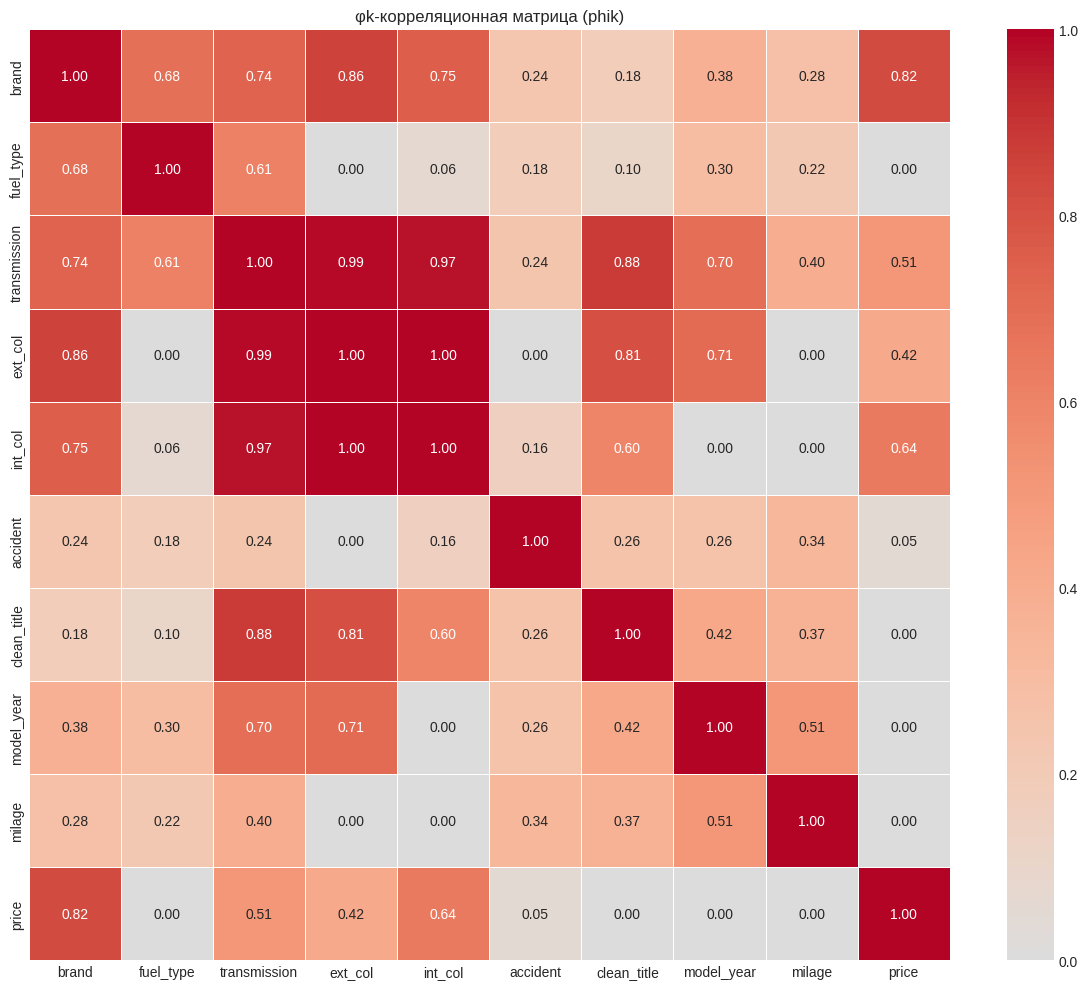


=== Корреляция признаков с ценой (φk) ===



,phik_with_price,phik
brand,0.82,0.82
int_col,0.64,0.64
transmission,0.51,0.51
ext_col,0.42,0.42
accident,0.05,0.05
fuel_type,0.00,0.00
clean_title,0.00,0.00
model_year,0.00,0.00
milage,0.00,0.00


In [ ]:
# 6.11. Корреляция φk через phik
print('\n=== 6.11. Корреляция φk (phik matrix) ===\n')

from phik import phik_matrix

# Список столбцов для корреляции
phik_cols = [
    'brand', 'fuel_type', 'transmission', 'ext_col', 'int_col',
    'accident', 'clean_title', 'model_year', 'milage', 'price'
]

# Вычисление φk-матрицы
# interval_cols — числовые столбцы
phik_corr = phik_matrix(
    clean[phik_cols],
    interval_cols=['model_year', 'milage', 'price']
)

display(phik_corr.round(2))

# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(
    phik_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=False
)
plt.title('φk-корреляционная матрица (phik)')
plt.tight_layout()
plt.show()

# Корреляция с ценой
print('\n=== Корреляция признаков с ценой (φk) ===\n')

price_corr = (
    phik_corr['price']
    .drop('price')
    .sort_values(ascending=False)
    .to_frame('phik_with_price')
    .assign(phik=lambda x: x['phik_with_price'].round(3))
)
display(price_corr)

## 7. Итоговые выводы

Сформулируйте итоговый отчёт по результатам EDA. В отчёте отразите:

**Качество данных:**
- Какие проблемы обнаружены?
- Как вы их решили?
- Что рекомендуете улучшить при сборе данных?

**Ключевые находки:**
- Самые интересные закономерности, аномалии и взаимосвязи

**Рекомендации:**
- На что стоит обратить внимание при дальнейшем анализе или построении ценовой модели


**Ваши итоговые выводы:**

1. **Качество данных.**
- Датасет содержит 4009 строк и 12 признаков. Полных дубликатов не обнаружено. Найдены 3 строки с совпадающими значениями потенциального ключа brand + model + model_year + milage; перед удалением их нужно проверять по идентификатору объявления или VIN.
- Главная техническая проблема — числовые признаки milage и price записаны в строковом формате. Они были очищены от единиц измерения, символов валюты и разделителей тысяч, после чего преобразованы в числовой тип.
- Пропуски обнаружены в трёх столбцах:
fuel_type — 4,24%;
accident — 2,82%;
clean_title — 14,87%.
- Пропуски были заменены на категорию Unknown, поскольку отсутствие значения не обязательно означает отсутствие соответствующего свойства.

2. **Основные находки.**
- Наиболее распространённое топливо — бензин: 82,54%.
- Наиболее распространённые марки — Ford, BMW, Mercedes-Benz и Chevrolet.
- Медианная цена автомобиля составляет 31 000 долларов, а средняя — 44 553 доллара.
- Цена сильно скошена вправо из-за дорогих автомобилей; максимальное значение — 2 954 083 доллара.
- Медианный пробег составляет 52 775 миль.
- Автомобили с историей ДТП имеют медианную цену 20 900 долларов против 35 667,5 доллара для автомобилей без зарегистрированных ДТП.
- Более новые автомобили обычно имеют меньший пробег и более высокую цену.
- Porsche, Land Rover и Mercedes-Benz имеют более высокие медианные цены, чем массовые марки вроде Toyota и Nissan.
- Корреляция цены с пробегом отрицательная, но умеренная, а корреляция с годом выпуска положительная, но слабая в линейном смысле.

3. **Рекомендации.**
- Проверить экстремальные цены, особенно значения выше 250–300 тысяч долларов.
- Анализировать цену в логарифмической шкале.
- Не удалять выбросы пробега и цены без проверки исходных объявлений.
- Нормализовать transmission:
выделить тип коробки: automatic/manual/CVT;
отдельно извлечь количество передач;
стандартизировать варианты A/T, Automatic, M/T, Manual.
- Разобрать engine на отдельные признаки:
объём двигателя;
мощность;
количество цилиндров;
тип двигателя.
- Учитывать взаимодействие года выпуска, пробега, марки и модели при моделировании цены.
- Проверить, не является ли отсутствие clean_title систематическим признаком источника объявления или определённого типа автомобиля.
- Для сравнения марок использовать медианные цены и минимальный размер группы, например не менее 30 объявлений.
- Для ценовой модели использовать кросс-валидацию и логарифмированную целевую переменную.
- При сборе данных добавить уникальный идентификатор объявления, VIN, дату публикации, регион, комплектацию и более структурированные поля двигателя и трансмиссии.